# Shortest-Path Algorithm Benchmark — Dijkstra vs A* vs ALT

Benchmarks the three routing algorithms on the **actual BIXI workload**: the road network of
Montreal (bike + walk composed graph, as established in `shortest_path_testing.ipynb`) queried
with real origin–destination pairs sampled from the 2025 trip data.

The pipeline in `bixi_montreal.ipynb` runs one shortest-path query per unique OD pair — tens of
thousands of queries against a graph with hundreds of thousands of nodes. That makes the choice of
routing algorithm the dominant cost of the whole project, and that is what this notebook measures.

**The three contenders**

| | Source | Heuristic | Preprocessing |
|---|---|---|---|
| **Dijkstra** | `nx.single_source_dijkstra` | none (uninformed) | none |
| **A\*** | `nx.astar_path` | great-circle distance to target | none |
| **ALT** | `nx.astar_path` + our heuristic | landmark triangle-inequality bound | **yes** — Dijkstra from each landmark |

ALT (**A**\*, **L**andmarks, **T**riangle inequality) is the only one that trades an up-front
preprocessing cost for faster queries. Whether that trade pays off is the question this notebook
is built to answer — and since the OD pairs are reused across ~24 hourly snapshots, amortizing
preprocessing over many queries is exactly the regime ALT is designed for.

**What we measure**
1. *Correctness* — do A* and ALT return genuinely optimal paths (same cost as Dijkstra)?
2. *Admissibility* — does the ALT heuristic ever overestimate? (If it does, optimality is void.)
3. *Query time* — wall-clock per query.
4. *Search space* — edges relaxed per query, the implementation-independent measure of work.
5. *Preprocessing cost* — time and memory ALT must pay before answering anything.
6. *Scaling* — how the speedup varies with trip distance and with landmark count.

In [26]:
import math
import pickle
import random
import time
import pathlib
import json
from collections import defaultdict

import networkx as nx
import osmnx as ox
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

# --- Config ---
CSV_2025   = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2025_010203040506070809101112.csv"
OUTPUT_DIR = pathlib.Path("output")
CACHE_DIR  = pathlib.Path("cache")
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

WEIGHT     = "length"   # edge attribute routed on (metres)
N_QUERIES  = 200        # OD pairs in the microbenchmark set (sections 2-7)
PIPE_N     = 5_000      # unique OD pairs routed per algorithm in the pipeline benchmark (section 8)
K_MAX      = 8          # landmarks for the headline ALT config (matches bixi_montreal.ipynb)
SEED       = 42

# Ground-truth calibration: the real A* full run of the bixi_montreal pipeline.
# 537,918 unique OD pairs routed with A* in 20,676.6 s (= 38.4 ms/pair). Set to None to hide.
ASTAR_OBSERVED_S     = None
ASTAR_OBSERVED_PAIRS = None

random.seed(SEED)
np.random.seed(SEED)

# --- Plot style (matches the rest of the project: dark surface, validated palette) ---
BG      = "#0d0d0d"   # page plane
INK     = "#ffffff"   # primary ink
INK_2   = "#c3c2b7"   # secondary ink
MUTED   = "#898781"   # axis / labels
GRID    = "#2c2c2a"   # hairline gridline
AXIS    = "#383835"   # baseline

# Colour follows the algorithm, never its rank -- fixed across every figure below.
COLOR = {
    "Dijkstra": "#3987e5",   # categorical slot 1 (blue)
    "A*":       "#199e70",   # categorical slot 2 (aqua)
    "ALT":      "#c98500",   # categorical slot 3 (yellow)
}
ALGOS = ["Dijkstra", "A*", "ALT"]

def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply the project's dark chart chrome to an axes."""
    ax.set_facecolor(BG)
    if title:  ax.set_title(title, color=INK, fontsize=14, pad=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK_2, fontsize=11)
    if ylabel: ax.set_ylabel(ylabel, color=INK_2, fontsize=11)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side, spine in ax.spines.items():
        spine.set_edgecolor(AXIS if side in ("bottom", "left") else BG)
    return ax

## 1. Build the benchmark graph

Same construction as `bixi_montreal.ipynb` — `nx.compose` of the bike and walk networks, because
cyclists share several key links (notably the Jacques-Cartier bridge) with pedestrians, and a
bike-only graph silently drops them.

One addition: we restrict to the **largest strongly connected component**. In the full composed
graph some node pairs have no directed path at all — `bixi_montreal.ipynb` catches these as
`NetworkXNoPath` and skips them. For a benchmark that would be a confound: a "no path" query is
answered by exhausting the reachable component, which is a completely different amount of work than
finding a path. Restricting to the largest SCC guarantees every sampled query is routable, so all
three algorithms are solving the same problem on every pair.

We keep **both** graphs. `G` (the SCC) is the clean microbenchmark surface used in sections 2–7.
`G_FULL` (the composed graph, exactly as `bixi_montreal.ipynb` builds it) is what the real pipeline
routes on, and section 8 benchmarks against it — including the cost of the queries that fail.

Both are cached to `cache/` (gitignored) so this cell is slow exactly once.

In [27]:
GRAPH_CACHE      = CACHE_DIR / "montreal_bike_walk_scc.pkl"
GRAPH_FULL_CACHE = CACHE_DIR / "montreal_bike_walk_full.pkl"

if GRAPH_CACHE.exists() and GRAPH_FULL_CACHE.exists():
    with open(GRAPH_CACHE, "rb") as f:
        G = pickle.load(f)
    with open(GRAPH_FULL_CACHE, "rb") as f:
        G_FULL = pickle.load(f)
    print(f"Loaded cached graphs from {CACHE_DIR}/")
else:
    t0 = time.perf_counter()
    G_bike = ox.graph.graph_from_place("Montreal, Quebec, Canada", network_type="bike")
    G_walk = ox.graph.graph_from_place("Montreal, Quebec, Canada", network_type="walk")
    G_FULL = nx.compose(G_bike, G_walk)
    print(f"Composed graph: {G_FULL.number_of_nodes():,} nodes | "
          f"{G_FULL.number_of_edges():,} edges  ({time.perf_counter()-t0:.0f}s)")

    scc = max(nx.strongly_connected_components(G_FULL), key=len)
    G = G_FULL.subgraph(scc).copy()
    kept = G.number_of_nodes() / G_FULL.number_of_nodes()
    print(f"Largest SCC:    {G.number_of_nodes():,} nodes "
          f"({kept:.1%} of the composed graph retained)")

    with open(GRAPH_CACHE, "wb") as f:
        pickle.dump(G, f)
    with open(GRAPH_FULL_CACHE, "wb") as f:
        pickle.dump(G_FULL, f)
    print(f"Cached to {CACHE_DIR}/")

N_NODES, N_EDGES = G.number_of_nodes(), G.number_of_edges()
print(f"\nMicrobenchmark graph (SCC): {N_NODES:,} nodes | {N_EDGES:,} edges")
print(f"Pipeline graph (composed):  {G_FULL.number_of_nodes():,} nodes | "
      f"{G_FULL.number_of_edges():,} edges")

Loaded cached graphs from cache/

Microbenchmark graph (SCC): 163,701 nodes | 514,294 edges
Pipeline graph (composed):  163,769 nodes | 514,387 edges


## 2. Sample a realistic query workload

A benchmark on uniformly-random node pairs would measure the wrong thing. Real BIXI trips are not
uniform: they are short, they concentrate downtown, and popular OD pairs repeat thousands of times.
A* and ALT both exploit *goal direction*, and their advantage depends strongly on how far apart the
endpoints are — so the query set has to look like the real one or the numbers are fiction.

We therefore sample OD pairs **from the actual 2025 trip table**, weighted by trip frequency, so a
corridor that carries 5,000 rides is 5,000× more likely to be benchmarked than one that carries a
single ride. Each pair is also tagged with its straight-line distance so we can later break the
results down by trip length.

In [28]:
cols = ["STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE",
        "ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"]

t0 = time.perf_counter()
chunks = []
for chunk in pd.read_csv(CSV_2025, usecols=cols, chunksize=200_000, low_memory=False):
    chunks.append(chunk.dropna())
trips = pd.concat(chunks, ignore_index=True)
print(f"{len(trips):,} trips loaded ({time.perf_counter()-t0:.0f}s)")

14,197,540 trips loaded (34s)


In [29]:
# Snap every station to its nearest node in the benchmark graph
station_coords = {}
for name_c, lat_c, lon_c in [
    ("STARTSTATIONNAME", "STARTSTATIONLATITUDE", "STARTSTATIONLONGITUDE"),
    ("ENDSTATIONNAME",   "ENDSTATIONLATITUDE",   "ENDSTATIONLONGITUDE"),
]:
    for _, r in trips[[name_c, lat_c, lon_c]].drop_duplicates(name_c).iterrows():
        station_coords[r[name_c]] = (r[lat_c], r[lon_c])

names = list(station_coords)
nodes = ox.distance.nearest_nodes(
    G,
    [station_coords[n][1] for n in names],
    [station_coords[n][0] for n in names],
)
station_to_node = dict(zip(names, nodes))

trips["src_node"] = trips["STARTSTATIONNAME"].map(station_to_node)
trips["dst_node"] = trips["ENDSTATIONNAME"].map(station_to_node)
trips = trips.dropna(subset=["src_node", "dst_node"])
trips["src_node"] = trips["src_node"].astype(int)
trips["dst_node"] = trips["dst_node"].astype(int)
trips = trips[trips["src_node"] != trips["dst_node"]]

pair_counts = trips.groupby(["src_node", "dst_node"]).size()
print(f"{len(station_to_node):,} stations snapped | {len(pair_counts):,} unique OD pairs")

1,302 stations snapped | 537,918 unique OD pairs


In [30]:
# Sample N_QUERIES distinct OD pairs, weighted by how often they are actually ridden.
pairs_df = pair_counts.reset_index(name="count")
weights  = pairs_df["count"] / pairs_df["count"].sum()
idx = np.random.choice(len(pairs_df), size=min(N_QUERIES, len(pairs_df)),
                       replace=False, p=weights)

QUERIES = []
for i in idx:
    s, t = int(pairs_df.src_node[i]), int(pairs_df.dst_node[i])
    ns, nt = G.nodes[s], G.nodes[t]
    QUERIES.append({
        "src": s,
        "dst": t,
        "rides": int(pairs_df["count"][i]),
        "crow_m": ox.distance.great_circle(ns["y"], ns["x"], nt["y"], nt["x"]),
    })

crow = np.array([q["crow_m"] for q in QUERIES])
print(f"{len(QUERIES)} benchmark queries")
print(f"Straight-line distance: median {np.median(crow):,.0f} m | "
      f"range {crow.min():,.0f}–{crow.max():,.0f} m")
print(f"Rides represented: {sum(q['rides'] for q in QUERIES):,}")

200 benchmark queries
Straight-line distance: median 1,543 m | range 86–8,072 m
Rides represented: 52,486


## 3. The three algorithms

### Dijkstra and A* — NetworkX built-ins

Both come straight from NetworkX. A* uses the same great-circle heuristic already used in
`bixi_montreal.ipynb`: the straight-line distance from a node to the target. It is admissible
because no road can be shorter than the crow-flies distance, which is exactly the property that
guarantees A* still returns an optimal path.

In [31]:
def euclid_heuristic(G, target):
    """Great-circle distance to target -- admissible because roads can't beat a straight line."""
    nt = G.nodes[target]
    ty, tx = nt["y"], nt["x"]
    def h(u, _v):
        nu = G.nodes[u]
        return ox.distance.great_circle(nu["y"], nu["x"], ty, tx)
    return h


def run_dijkstra(G, s, t, weight=WEIGHT):
    return nx.single_source_dijkstra(G, s, t, weight=weight)[1]


def run_astar(G, s, t, weight=WEIGHT):
    return nx.astar_path(G, s, t, heuristic=euclid_heuristic(G, t), weight=weight)

### ALT — preprocessing

ALT's premise: if we precompute the exact distance between every node and a handful of **landmarks**,
the triangle inequality turns those distances into a *lower bound* on the distance between any two
nodes — and a lower bound is precisely what A* needs as a heuristic.

Because the road graph is **directed**, distance is not symmetric and each landmark `L` needs two
tables:

- `dist_from[L][v] = d(L, v)` — one Dijkstra from `L` on `G`
- `dist_to[L][v]   = d(v, L)` — one Dijkstra from `L` on the **reversed** graph

So preprocessing is `2k` full single-source Dijkstra runs. That is the price of admission.

**Landmark placement matters more than landmark count.** A landmark only produces a tight bound for
nodes that lie roughly "behind" or "beyond" it, so landmarks bunched together are largely redundant.
We implement the standard *greedy farthest-point* selection — repeatedly add the node that is
farthest from every landmark chosen so far, which pushes landmarks out to the corners of the map —
and also a `random` strategy to demonstrate the difference.

One useful property of greedy farthest selection: **any prefix of the landmark list is itself a
valid landmark set.** We exploit that below to sweep landmark count without re-preprocessing.

In [32]:
def alt_preprocess(G, k=K_MAX, weight=WEIGHT, strategy="farthest", seed=SEED, verbose=True):
    """Select k landmarks and compute exact distances to and from each.

    Returns dict with landmarks, dist_from, dist_to, and cumulative timing per landmark
    (so a k'-landmark prefix can be costed without re-running).
    """
    rng = random.Random(seed)
    G_rev = G.reverse(copy=False)          # a view -- no copy of the edge data
    nodes = list(G.nodes())
    t_start = time.perf_counter()

    # --- landmark selection ---
    if strategy == "random":
        landmarks = rng.sample(nodes, k)
    elif strategy == "farthest":
        # Seed from the node farthest from an arbitrary start, then greedily add the
        # node maximising its minimum distance to the landmarks chosen so far.
        d0 = nx.single_source_dijkstra_path_length(G, rng.choice(nodes), weight=weight)
        landmarks = [max(d0, key=d0.get)]
        mindist = nx.single_source_dijkstra_path_length(G, landmarks[0], weight=weight)
        while len(landmarks) < k:
            nxt = max(mindist, key=mindist.get)
            landmarks.append(nxt)
            dn = nx.single_source_dijkstra_path_length(G, nxt, weight=weight)
            for v, dv in dn.items():
                if v in mindist and dv < mindist[v]:
                    mindist[v] = dv
            if verbose:
                print(f"\r  selecting landmarks {len(landmarks)}/{k}", end="", flush=True)
    else:
        raise ValueError(f"unknown strategy: {strategy}")
    t_select = time.perf_counter() - t_start

    # --- the two distance tables per landmark ---
    dist_from, dist_to, cum_time = {}, {}, []
    t0 = time.perf_counter()
    for i, L in enumerate(landmarks):
        dist_from[L] = nx.single_source_dijkstra_path_length(G, L, weight=weight)
        dist_to[L]   = nx.single_source_dijkstra_path_length(G_rev, L, weight=weight)
        cum_time.append(time.perf_counter() - t0)
        if verbose:
            print(f"\r  landmark distances {i+1}/{k}  ({cum_time[-1]:.0f}s)", end="", flush=True)

    total = time.perf_counter() - t_start
    if verbose:
        print(f"\r  {strategy}: {k} landmarks preprocessed in {total:.1f}s "
              f"({t_select:.1f}s selecting + {cum_time[-1]:.1f}s distances)      ")

    return {"landmarks": landmarks, "dist_from": dist_from, "dist_to": dist_to,
            "select_time": t_select, "cum_time": cum_time, "total_time": total,
            "strategy": strategy}

### ALT — the heuristic

For a landmark `L`, the triangle inequality gives two independent lower bounds on `d(u, t)`:

```
d(u, t)  >=  d(L, t) - d(L, u)      # L sits "behind" u
d(u, t)  >=  d(u, L) - d(t, L)      # L sits "beyond" t
```

Each is a valid lower bound, so the **maximum over all landmarks and both forms** is also a valid
lower bound — and the tighter it is, the more of the graph A* can prune. Clamping at zero keeps it
non-negative.

Two implementation details that matter:

- The target `t` is fixed for a given query, so `d(L,t)` and `d(t,L)` are hoisted out of the inner
  loop and resolved **once per query**, not once per node expansion.
- A node may be unreachable from a landmark, leaving a gap in the table. Those terms are *skipped*
  rather than treated as zero — a missing distance carries no information, and inventing one would
  break admissibility.

In [33]:
def alt_heuristic(pre, target):
    """Build the ALT lower-bound heuristic h(u, target) for one fixed target."""
    # Resolve the target's landmark distances once, up front.
    rows = []
    for L in pre["landmarks"]:
        df, dt = pre["dist_from"][L], pre["dist_to"][L]
        dL_t, dt_L = df.get(target), dt.get(target)
        if dL_t is not None or dt_L is not None:
            rows.append((df, dt, dL_t, dt_L))

    def h(u, _v):
        best = 0.0
        for df, dt, dL_t, dt_L in rows:
            if dL_t is not None:                    # d(L,t) - d(L,u)
                dL_u = df.get(u)
                if dL_u is not None and (b := dL_t - dL_u) > best:
                    best = b
            if dt_L is not None:                    # d(u,L) - d(t,L)
                du_L = dt.get(u)
                if du_L is not None and (b := du_L - dt_L) > best:
                    best = b
        return best

    return h


def run_alt(G, s, t, pre, weight=WEIGHT):
    return nx.astar_path(G, s, t, heuristic=alt_heuristic(pre, t), weight=weight)

In [34]:
PRE = alt_preprocess(G, k=K_MAX, strategy="farthest")

# Memory footprint: 2 tables x k landmarks x N nodes, each a {node: float} entry.
n_entries = sum(len(d) for d in PRE["dist_from"].values()) + \
            sum(len(d) for d in PRE["dist_to"].values())
alt_mb = n_entries * 68 / 1e6   # ~68 B/entry for a CPython dict int->float
print(f"\nLandmark tables: {n_entries:,} distance entries (~{alt_mb:,.0f} MB)")

  farthest: 8 landmarks preprocessed in 19.3s (7.0s selecting + 12.4s distances)      

Landmark tables: 2,619,216 distance entries (~178 MB)


## 4. Correctness and admissibility

Before timing anything, the results have to be *right*. Speed is worthless if the path is wrong,
and a fast-but-inadmissible heuristic is the classic way to get a plausible-looking wrong answer.

Two checks:

1. **Optimality** — all three algorithms must return a path of identical cost. (Not necessarily the
   identical node sequence: ties are broken arbitrarily and several equal-length routes usually
   exist.)
2. **Admissibility** — walking the optimal path node by node, the ALT heuristic must never exceed
   the true remaining distance to the target. A single overestimate anywhere voids A*'s optimality
   guarantee, so this asserts rather than warns.

The `h/d` ratio reported at the end is the *tightness* of the bound: 1.0 would mean the heuristic
knows the exact distance and A* walks straight to the target expanding nothing extra; 0.0 would mean
it knows nothing and A* degenerates into Dijkstra.

In [35]:
def path_cost(G, path, weight=WEIGHT):
    return sum(min(a.get(weight, 1.0) for a in G[u][v].values())
               for u, v in zip(path[:-1], path[1:]))


check_pairs = QUERIES[:25]
n_checks, worst_ratio, ratios = 0, 0.0, []

for q in check_pairs:
    s, t = q["src"], q["dst"]
    d_cost, d_path = nx.single_source_dijkstra(G, s, t, weight=WEIGHT)
    a_path = run_astar(G, s, t)
    l_path = run_alt(G, s, t, PRE)

    assert abs(path_cost(G, a_path) - d_cost) < 1e-6, f"A* suboptimal on {s}->{t}"
    assert abs(path_cost(G, l_path) - d_cost) < 1e-6, f"ALT suboptimal on {s}->{t}"

    # Admissibility along the optimal path: h(u,t) must never exceed true remaining distance.
    h = alt_heuristic(PRE, t)
    remaining = d_cost
    for u, v in zip(d_path[:-1], d_path[1:]):
        hv = h(u, t)
        assert hv <= remaining + 1e-6, f"INADMISSIBLE at {u}: h={hv:.1f} > d={remaining:.1f}"
        n_checks += 1
        if remaining > 1.0:
            ratios.append(hv / remaining)
            worst_ratio = max(worst_ratio, hv / remaining)
        remaining -= min(a.get(WEIGHT, 1.0) for a in G[u][v].values())

print(f"Optimality:     {len(check_pairs)}/{len(check_pairs)} pairs — Dijkstra, A* and ALT agree on path cost")
print(f"Admissibility:  {n_checks:,}/{n_checks:,} checks passed — ALT heuristic never overestimates")
print(f"Bound tightness: mean h/d = {np.mean(ratios):.3f} | max = {worst_ratio:.3f}   (1.0 = exact)")

Optimality:     25/25 pairs — Dijkstra, A* and ALT agree on path cost
Admissibility:  1,565/1,565 checks passed — ALT heuristic never overestimates
Bound tightness: mean h/d = 0.964 | max = 1.000   (1.0 = exact)


## 5. The benchmark

Two separate passes, deliberately — because you cannot measure time and work with the same run.

**Pass A — wall-clock time.** Each algorithm runs with `weight="length"` (the string form), which is
the fast path NetworkX optimises for. This is the honest number: what the code actually costs.

**Pass B — search space.** Each algorithm re-runs with a *counting callable* in place of the weight
string. NetworkX invokes `weight(u, v, data)` once per adjacent edge it scans, so incrementing a
counter there yields the number of **edge relaxations** — the implementation-independent measure of
how much of the graph each algorithm had to look at.

Passing a callable makes every algorithm slower (a Python call per edge instead of a dict lookup),
which is exactly why it is quarantined into its own pass. Mixing the two would tax Dijkstra hardest —
it scans the most edges — and flatter the algorithms we are hoping to see win. Same overhead applies
to all three here, so the *ratios* stay meaningful even though the absolute counts come from a
slower run.

In [36]:
def counting_weight(counter, attr=WEIGHT):
    """Weight callable that tallies every edge NetworkX scans, and the nodes it settles."""
    def w(u, v, d):
        counter["edges"] += 1
        counter["nodes"].add(u)
        return min(a.get(attr, 1.0) for a in d.values())
    return w


rows = []
t_bench = time.perf_counter()

for i, q in enumerate(QUERIES):
    s, t = q["src"], q["dst"]
    if i % 20 == 0:
        print(f"\r  {i}/{len(QUERIES)} queries  ({time.perf_counter()-t_bench:.0f}s)", end="", flush=True)

    # --- Pass A: wall-clock, uninstrumented ---
    t0 = time.perf_counter(); p_d = run_dijkstra(G, s, t);      t_d = time.perf_counter() - t0
    t0 = time.perf_counter(); p_a = run_astar(G, s, t);         t_a = time.perf_counter() - t0

    # ALT's per-query heuristic build (resolving the target's landmark rows) is part of
    # its query cost, so it is timed inside the query, not hoisted out.
    t0 = time.perf_counter(); p_l = run_alt(G, s, t, PRE);      t_l = time.perf_counter() - t0

    # --- Pass B: search space, instrumented ---
    c = {"edges": 0, "nodes": set()}
    nx.single_source_dijkstra(G, s, t, weight=counting_weight(c))
    e_d, n_d = c["edges"], len(c["nodes"])

    c = {"edges": 0, "nodes": set()}
    nx.astar_path(G, s, t, heuristic=euclid_heuristic(G, t), weight=counting_weight(c))
    e_a, n_a = c["edges"], len(c["nodes"])

    c = {"edges": 0, "nodes": set()}
    nx.astar_path(G, s, t, heuristic=alt_heuristic(PRE, t), weight=counting_weight(c))
    e_l, n_l = c["edges"], len(c["nodes"])

    rows.append({
        "src": s, "dst": t, "rides": q["rides"], "crow_m": q["crow_m"],
        "route_m": path_cost(G, p_d), "hops": len(p_d),
        "Dijkstra_time": t_d, "A*_time": t_a, "ALT_time": t_l,
        "Dijkstra_edges": e_d, "A*_edges": e_a, "ALT_edges": e_l,
        "Dijkstra_nodes": n_d, "A*_nodes": n_a, "ALT_nodes": n_l,
    })

bench = pd.DataFrame(rows)
print(f"\r  {len(QUERIES)}/{len(QUERIES)} queries complete ({time.perf_counter()-t_bench:.0f}s)      ")
bench.head()

  200/200 queries complete (37s)      


,src,dst,rides,crow_m,route_m,hops,Dijkstra_time,A*_time,ALT_time,Dijkstra_edges,A*_edges,ALT_edges,Dijkstra_nodes,A*_nodes,ALT_nodes
0,10157460545,213839108,24,1785.437866,2456.646145,37,0.061344,0.017933,0.004345,38775,6337,878,12471,1975,277
1,12844601652,11357224377,32,1674.757835,1773.114827,45,0.030216,0.003530,0.006125,21177,976,1160,6995,320,394
2,11492813398,2467762073,150,1299.313355,1309.939376,40,0.017635,0.000726,0.001302,11524,162,189,3754,54,59
3,11176648099,476659899,39,2171.855658,2577.427795,84,0.064921,0.018061,0.017625,43133,6065,3978,13790,1908,1253
4,6893619151,11815832987,203,2338.601254,2903.787855,100,0.069822,0.025537,0.010403,47811,9213,2073,15801,3085,655


In [37]:
summary = pd.DataFrame({
    "median query (ms)": [bench[f"{a}_time"].median() * 1e3 for a in ALGOS],
    "mean query (ms)":   [bench[f"{a}_time"].mean()   * 1e3 for a in ALGOS],
    "speedup vs Dijkstra": [bench["Dijkstra_time"].median() / bench[f"{a}_time"].median() for a in ALGOS],
    "edges relaxed":     [bench[f"{a}_edges"].mean() for a in ALGOS],
    "nodes settled":     [bench[f"{a}_nodes"].mean() for a in ALGOS],
    "graph explored":    [bench[f"{a}_nodes"].mean() / N_NODES for a in ALGOS],
}, index=ALGOS)

print(f"Benchmark: {len(bench)} real BIXI OD pairs on {N_NODES:,} nodes / {N_EDGES:,} edges\n")
summary.style.format({
    "median query (ms)": "{:.1f}", "mean query (ms)": "{:.1f}",
    "speedup vs Dijkstra": "{:.2f}x", "edges relaxed": "{:,.0f}",
    "nodes settled": "{:,.0f}", "graph explored": "{:.1%}",
})

Benchmark: 200 real BIXI OD pairs on 163,701 nodes / 514,294 edges



,median query (ms),mean query (ms),speedup vs Dijkstra,edges relaxed,nodes settled,graph explored
Dijkstra,26.7,56.4,1.00x,"34,479","11,106",6.8%
A*,5.2,13.6,5.17x,"4,506","1,435",0.9%
ALT,4.3,8.9,6.27x,"1,709",534,0.3%


## 6. Results

### Query time and search space

The two charts answer different questions and are kept on separate axes on purpose. **Time** is what
the pipeline actually pays. **Edges relaxed** is why: it strips out interpreter overhead and shows
how much of the graph each algorithm was forced to examine.

They will not agree exactly, and the gap is the interesting part — ALT prunes far more of the graph
than A* does, but pays for it with a heavier per-node heuristic (a loop over `k` landmarks, versus
one trig call), so its time advantage is smaller than its search-space advantage.

/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/3974454992.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


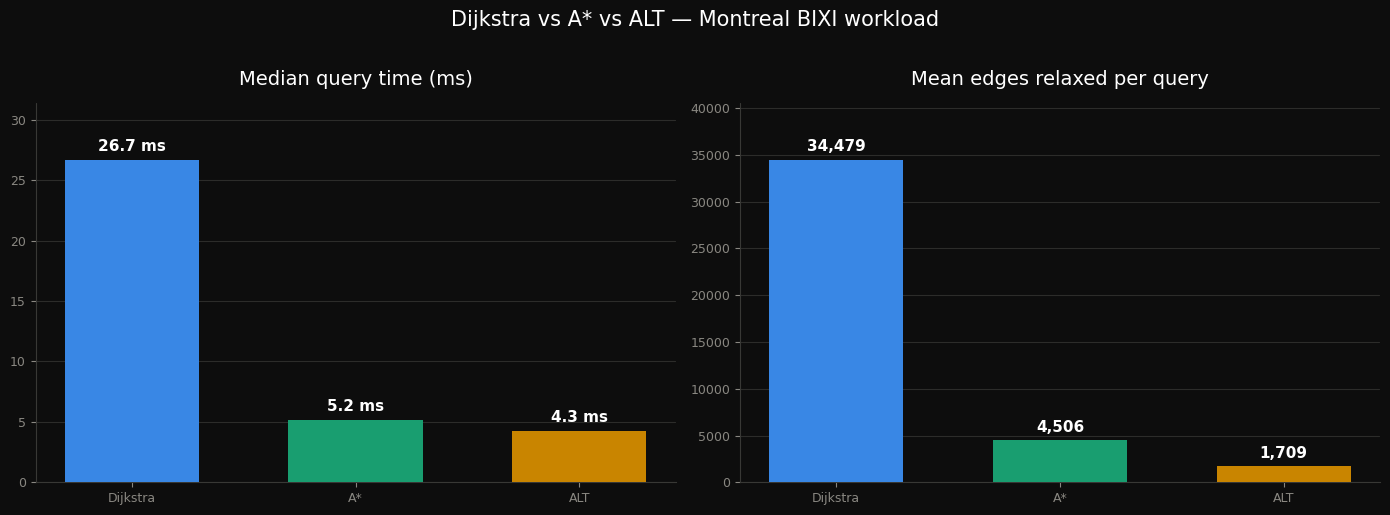

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

for ax, (metric, label, fmt, scale) in zip(axes, [
    ("time",  "Median query time (ms)",       "{:.1f} ms", 1e3),
    ("edges", "Mean edges relaxed per query", "{:,.0f}",   1),
]):
    vals = [(bench[f"{a}_{metric}"].median() if metric == "time"
             else bench[f"{a}_{metric}"].mean()) * scale for a in ALGOS]
    bars = ax.bar(ALGOS, vals, color=[COLOR[a] for a in ALGOS], width=0.6, zorder=3)

    # Direct value labels -- identity is never carried by colour alone.
    for b, v in zip(bars, vals):
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, v),
                    ha="center", va="bottom", color=INK, fontsize=11,
                    fontweight="bold", xytext=(0, 4), textcoords="offset points")

    style_axes(ax, title=label)   # title carries the measure; no redundant axis label
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_xlabel("")

fig.suptitle("Dijkstra vs A* vs ALT — Montreal BIXI workload", color=INK, fontsize=15, y=1.02)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_time_vs_edges.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

### Where the advantage comes from: trip distance

A*'s and ALT's whole trick is aiming at the target, so their payoff should grow with the distance
between endpoints — a long crosstown trip gives the heuristic room to prune, while for a two-block
hop there is nothing to prune. Dijkstra, being uninformed, expands a disc around the origin whose
area grows with the *square* of the radius regardless of where the target is.

Binning the queries by straight-line distance tests exactly that.

/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/3706472960.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


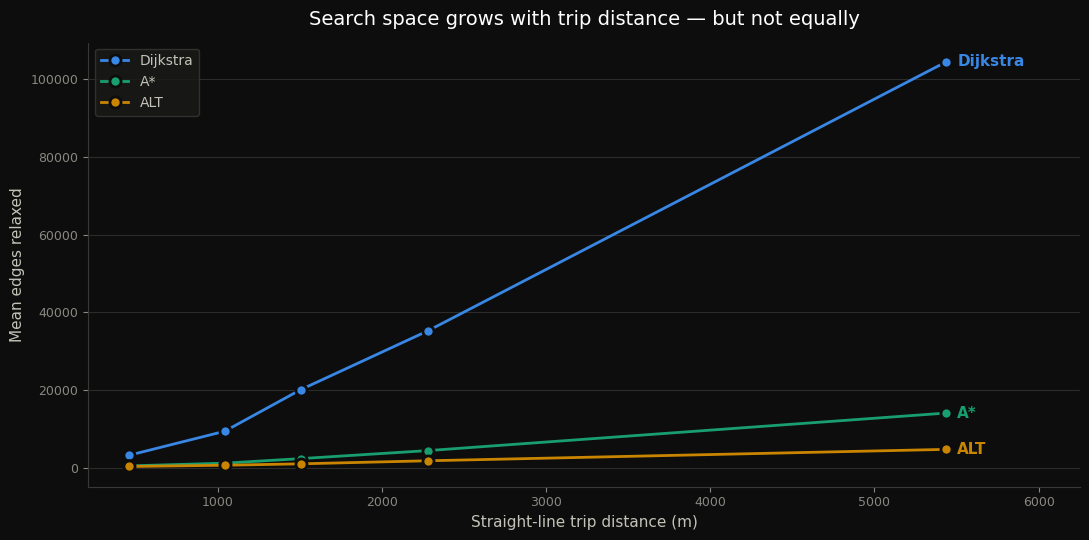

In [39]:
bench["dist_bin"] = pd.qcut(bench["crow_m"], q=5, precision=0)
by_dist = bench.groupby("dist_bin", observed=True)[[f"{a}_edges" for a in ALGOS]].mean()
centers = [iv.mid for iv in by_dist.index]

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(BG)

for a in ALGOS:
    y = by_dist[f"{a}_edges"]
    ax.plot(centers, y, color=COLOR[a], linewidth=2, marker="o", markersize=8,
            markeredgecolor=BG, markeredgewidth=2, label=a, zorder=3)
    # Direct end-label in addition to the legend.
    ax.annotate(a, (centers[-1], y.iloc[-1]), color=COLOR[a], fontsize=11, fontweight="bold",
                xytext=(8, 0), textcoords="offset points", va="center")

style_axes(ax, title="Search space grows with trip distance — but not equally",
           xlabel="Straight-line trip distance (m)", ylabel="Mean edges relaxed")
ax.set_xlim(right=centers[-1] * 1.15)
leg = ax.legend(facecolor="#1a1a19", edgecolor=AXIS, labelcolor=INK_2, fontsize=10)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_by_distance.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/3536247521.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


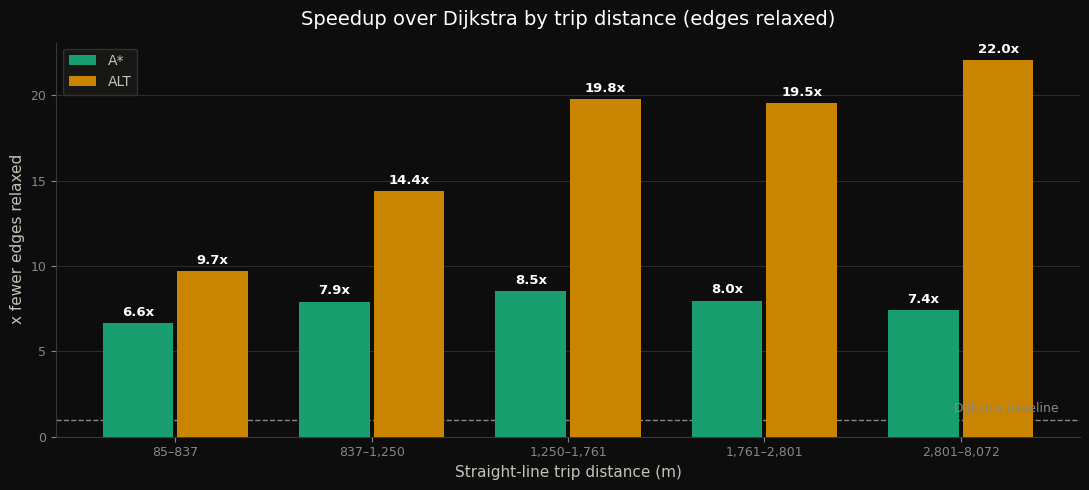

In [40]:
# Speedup vs Dijkstra, per distance bin -- the same data as a ratio, which is what actually matters.
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)

x = np.arange(len(by_dist))
w = 0.36
for i, a in enumerate(["A*", "ALT"]):
    speed = by_dist["Dijkstra_edges"] / by_dist[f"{a}_edges"]
    bars = ax.bar(x + (i - 0.5) * (w + 0.02), speed, width=w, color=COLOR[a], label=a, zorder=3)
    for b, v in zip(bars, speed):
        ax.annotate(f"{v:.1f}x", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                    color=INK, fontsize=9.5, fontweight="bold",
                    xytext=(0, 3), textcoords="offset points")

ax.axhline(1.0, color=MUTED, linewidth=1, linestyle="--", zorder=2)
ax.annotate("Dijkstra baseline", (len(x) - 0.5, 1.0), color=MUTED, fontsize=9,
            va="bottom", ha="right", xytext=(0, 3), textcoords="offset points")

style_axes(ax, title="Speedup over Dijkstra by trip distance (edges relaxed)",
           xlabel="Straight-line trip distance (m)", ylabel="x fewer edges relaxed")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(iv.left):,}–{int(iv.right):,}" for iv in by_dist.index], fontsize=9)
ax.legend(facecolor="#1a1a19", edgecolor=AXIS, labelcolor=INK_2, fontsize=10)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_speedup_by_distance.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

### The search space, drawn on the map

The clearest way to see what separates these algorithms is to plot the nodes each one actually
settles for a single long query.

Expect three characteristic shapes: Dijkstra a **disc** centred on the origin (it has no idea where
the target is, so it grows outward uniformly until it stumbles onto it); A* an **ellipse/cone**
leaning toward the target (the crow-flies bound pulls it in the right direction, but it is fooled by
the river, dead ends and one-way streets); ALT a **narrow corridor** hugging the route (its landmark
bounds encode real network distance, so it knows detours are detours before it walks them).

In [41]:
# Pick the longest query in the set -- the differences are starkest there.
q = bench.loc[bench["crow_m"].idxmax()]
s, t = int(q["src"]), int(q["dst"])

visited = {}
for name, fn in [
    ("Dijkstra", lambda w: nx.single_source_dijkstra(G, s, t, weight=w)),
    ("A*",       lambda w: nx.astar_path(G, s, t, heuristic=euclid_heuristic(G, t), weight=w)),
    ("ALT",      lambda w: nx.astar_path(G, s, t, heuristic=alt_heuristic(PRE, t), weight=w)),
]:
    c = {"edges": 0, "nodes": set()}
    fn(counting_weight(c))
    visited[name] = c["nodes"]

route = run_dijkstra(G, s, t)
print(f"Query: {s} -> {t} | {q['crow_m']:,.0f} m as the crow flies | "
      f"{q['route_m']:,.0f} m by road | {int(q['rides']):,} rides in 2025")
for a in ALGOS:
    print(f"  {a:<9} settled {len(visited[a]):>7,} nodes  ({len(visited[a])/N_NODES:.1%} of the graph)")

Query: 3405413740 -> 9588830726 | 8,072 m as the crow flies | 9,836 m by road | 2 rides in 2025
  Dijkstra  settled 100,120 nodes  (61.2% of the graph)
  A*        settled  23,826 nodes  (14.6% of the graph)
  ALT       settled   5,739 nodes  (3.5% of the graph)


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/2132969142.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


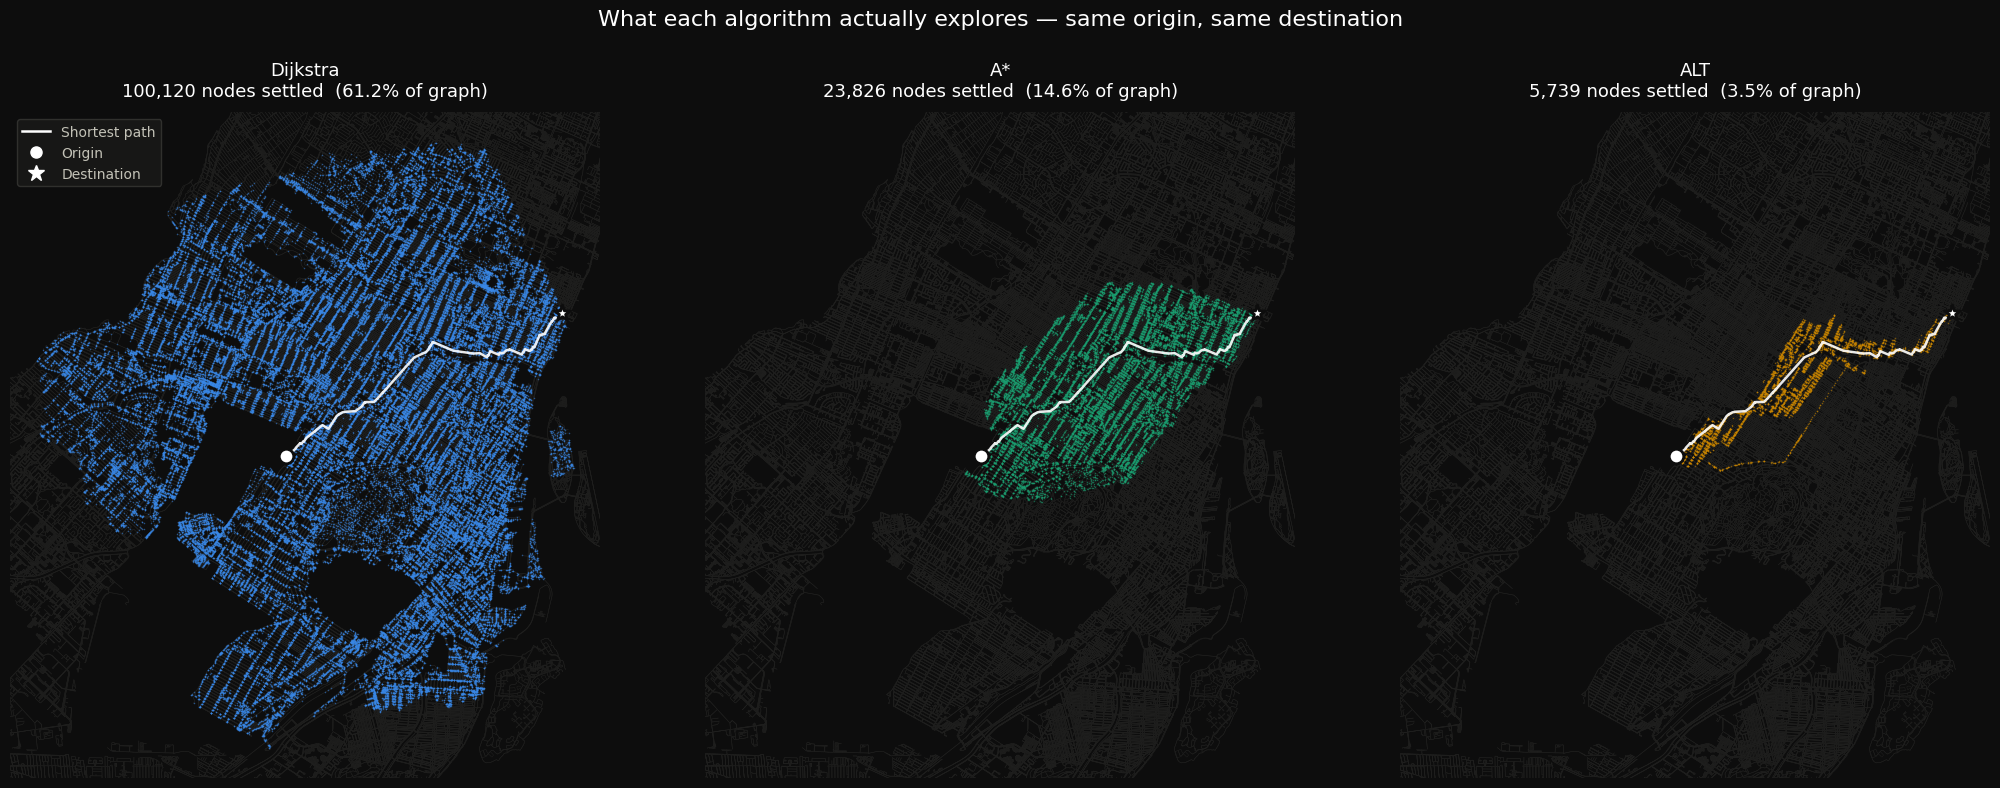

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.patch.set_facecolor(BG)

xs = np.array([G.nodes[n]["x"] for n in G.nodes()])
ys = np.array([G.nodes[n]["y"] for n in G.nodes()])
rx = [G.nodes[n]["x"] for n in route]
ry = [G.nodes[n]["y"] for n in route]

# Frame the panels on the union of all three search spaces, padded, so the shapes are comparable.
allv = set().union(*visited.values())
vx = np.array([G.nodes[n]["x"] for n in allv]); vy = np.array([G.nodes[n]["y"] for n in allv])
padx = (vx.max() - vx.min()) * 0.05; pady = (vy.max() - vy.min()) * 0.05

for ax, a in zip(axes, ALGOS):
    ax.set_facecolor(BG)
    ox.plot.plot_graph(G, ax=ax, node_size=0, edge_color="#1f1f1e", edge_linewidth=0.4,
                       bgcolor=BG, show=False, close=False)

    vis = list(visited[a])
    ax.scatter([G.nodes[n]["x"] for n in vis], [G.nodes[n]["y"] for n in vis],
               s=1.2, c=COLOR[a], alpha=0.55, linewidths=0, zorder=3)
    ax.plot(rx, ry, color=INK, linewidth=1.8, zorder=4, alpha=0.9)
    ax.scatter([G.nodes[s]["x"]], [G.nodes[s]["y"]], s=110, c="#ffffff",
               edgecolors=BG, linewidths=2, zorder=6, marker="o")
    ax.scatter([G.nodes[t]["x"]], [G.nodes[t]["y"]], s=150, c="#ffffff",
               edgecolors=BG, linewidths=2, zorder=6, marker="*")

    pct = len(visited[a]) / N_NODES
    ax.set_title(f"{a}\n{len(visited[a]):,} nodes settled  ({pct:.1%} of graph)",
                 color=INK, fontsize=13, pad=12)
    ax.set_xlim(vx.min() - padx, vx.max() + padx)
    ax.set_ylim(vy.min() - pady, vy.max() + pady)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(AXIS)

handles = [
    Line2D([], [], color=INK, linewidth=1.8, label="Shortest path"),
    Line2D([], [], color="#ffffff", marker="o", linestyle="", markersize=8, label="Origin"),
    Line2D([], [], color="#ffffff", marker="*", linestyle="", markersize=12, label="Destination"),
]
axes[0].legend(handles=handles, facecolor="#1a1a19", edgecolor=AXIS, labelcolor=INK_2,
               fontsize=10, loc="upper left")

fig.suptitle("What each algorithm actually explores — same origin, same destination",
             color=INK, fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUTPUT_DIR / "benchmark_search_space.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

### How many landmarks?

More landmarks mean a tighter bound and a smaller search space, but preprocessing grows linearly
(2 Dijkstras each) and so does the per-node heuristic cost (a loop over every landmark). Somewhere
there is a knee.

Because greedy farthest-point selection builds landmarks in a meaningful order, **the first `k'`
landmarks of our set are exactly the set greedy selection would have produced for `k'`** — so we can
sweep landmark count by slicing `PRE`, with no re-preprocessing. Preprocessing time for each `k'` is
read off the cumulative timings recorded during the run.

In [43]:
def prefix_pre(pre, k):
    L = pre["landmarks"][:k]
    return {"landmarks": L,
            "dist_from": {l: pre["dist_from"][l] for l in L},
            "dist_to":   {l: pre["dist_to"][l]   for l in L}}


# Derived from K_MAX so the sweep can never index past the landmarks we preprocessed.
K_SWEEP = sorted({k for k in (1, 2, 4, 8, 16, 32) if k <= K_MAX} | {K_MAX})
sweep_pairs = QUERIES[:60]
sweep = []

for k in K_SWEEP:
    sub = prefix_pre(PRE, k)
    edges, times = [], []
    for q in sweep_pairs:
        s, t = q["src"], q["dst"]
        t0 = time.perf_counter()
        nx.astar_path(G, s, t, heuristic=alt_heuristic(sub, t), weight=WEIGHT)
        times.append(time.perf_counter() - t0)
        c = {"edges": 0, "nodes": set()}
        nx.astar_path(G, s, t, heuristic=alt_heuristic(sub, t), weight=counting_weight(c))
        edges.append(c["edges"])
    sweep.append({
        "k": k,
        "edges": np.mean(edges),
        "query_ms": np.median(times) * 1e3,
        "prep_s": PRE["cum_time"][k - 1] + PRE["select_time"] * (k / K_MAX),
        "mem_mb": sum(len(d) for l, d in PRE["dist_from"].items() if l in sub["landmarks"]) * 2 * 68 / 1e6,
    })
    print(f"  k={k:>2}: {np.mean(edges):>9,.0f} edges | {np.median(times)*1e3:>6.1f} ms/query")

sweep = pd.DataFrame(sweep)

# Dijkstra / A* baselines, measured on the same subset the sweep used
_sweep_src = {q["src"] for q in sweep_pairs}
_sub = bench[bench["src"].isin(_sweep_src)]
dij_e = _sub["Dijkstra_edges"].mean()
ast_e = _sub["A*_edges"].mean()
sweep

  k= 1:    12,309 edges |   11.6 ms/query
  k= 2:     5,634 edges |    4.8 ms/query
  k= 4:     3,992 edges |    5.5 ms/query
  k= 8:     2,078 edges |    6.3 ms/query


,k,edges,query_ms,prep_s,mem_mb
0,1,12308.733333,11.593687,2.341850,22.263336
1,2,5633.583333,4.838750,4.773308,44.526672
2,4,3991.566667,5.519812,10.090862,89.053344
3,8,2077.566667,6.294667,19.307829,178.106688


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/3049038328.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


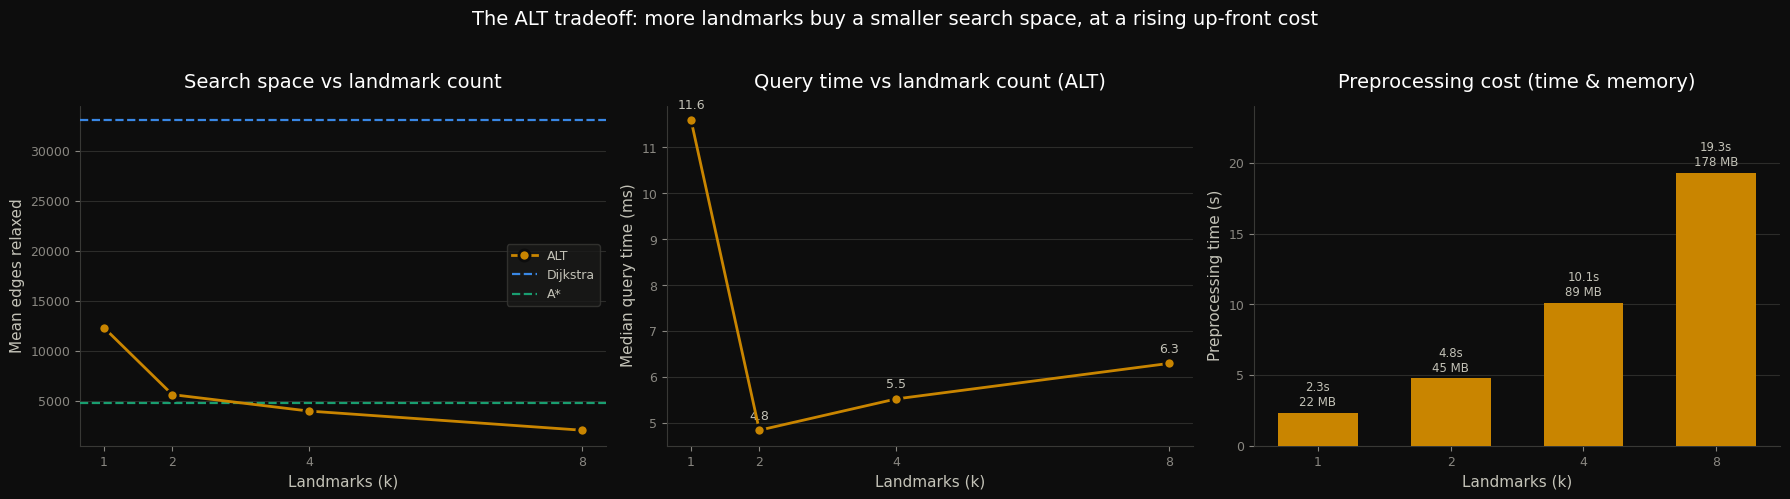

In [44]:
# Three separate single-axis panels -- never a dual axis.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
fig.patch.set_facecolor(BG)

# Panel 1: search space shrinks with k
ax = axes[0]
ax.plot(sweep["k"], sweep["edges"], color=COLOR["ALT"], linewidth=2, marker="o",
        markersize=8, markeredgecolor=BG, markeredgewidth=2, zorder=4, label="ALT")
ax.axhline(dij_e, color=COLOR["Dijkstra"], linewidth=1.6, linestyle="--", zorder=3, label="Dijkstra")
ax.axhline(ast_e, color=COLOR["A*"], linewidth=1.6, linestyle="--", zorder=3, label="A*")
style_axes(ax, title="Search space vs landmark count",
           xlabel="Landmarks (k)", ylabel="Mean edges relaxed")
ax.set_xticks(K_SWEEP)
ax.legend(facecolor="#1a1a19", edgecolor=AXIS, labelcolor=INK_2, fontsize=9)

# Panel 2: query time -- the U-shape, if there is one
ax = axes[1]
ax.plot(sweep["k"], sweep["query_ms"], color=COLOR["ALT"], linewidth=2, marker="o",
        markersize=8, markeredgecolor=BG, markeredgewidth=2, zorder=4)
for _, r in sweep.iterrows():
    ax.annotate(f"{r.query_ms:.1f}", (r.k, r.query_ms), color=INK_2, fontsize=9,
                xytext=(0, 8), textcoords="offset points", ha="center")
style_axes(ax, title="Query time vs landmark count (ALT)",
           xlabel="Landmarks (k)", ylabel="Median query time (ms)")
ax.set_xticks(K_SWEEP)

# Panel 3: what it costs you up front
ax = axes[2]
bars = ax.bar(sweep["k"].astype(str), sweep["prep_s"], color=COLOR["ALT"], width=0.6, zorder=3)
for b, r in zip(bars, sweep.itertuples()):
    ax.annotate(f"{r.prep_s:,.1f}s\n{r.mem_mb:,.0f} MB",
                (b.get_x() + b.get_width() / 2, r.prep_s), ha="center", va="bottom",
                color=INK_2, fontsize=8.5, xytext=(0, 3), textcoords="offset points")
style_axes(ax, title="Preprocessing cost (time & memory)",
           xlabel="Landmarks (k)", ylabel="Preprocessing time (s)")
ax.set_ylim(0, sweep["prep_s"].max() * 1.25)

fig.suptitle("The ALT tradeoff: more landmarks buy a smaller search space, at a rising up-front cost",
             color=INK, fontsize=14, y=1.03)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_landmark_sweep.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

### Landmark placement: farthest-point vs random

Landmark *count* is the obvious knob, but placement is the one that matters. A landmark only tightens
the bound for nodes roughly in line with it, so landmarks clustered in the middle of the map are
largely redundant with each other. Greedy farthest-point pushes them to the extremities, where they
"see" the whole graph.

Same `k`, same queries — only the placement rule differs.

In [45]:
PRE_RAND = alt_preprocess(G, k=K_MAX, strategy="random")

cmp_pairs = QUERIES[:60]
placement = {}
for label, pre in [("Farthest-point", PRE), ("Random", PRE_RAND)]:
    edges = []
    for q in cmp_pairs:
        c = {"edges": 0, "nodes": set()}
        nx.astar_path(G, q["src"], q["dst"], heuristic=alt_heuristic(pre, q["dst"]),
                      weight=counting_weight(c))
        edges.append(c["edges"])
    placement[label] = np.mean(edges)
    print(f"  {label:<15} {np.mean(edges):>9,.0f} mean edges relaxed")

print(f"\nFarthest-point explores {placement['Random']/placement['Farthest-point']:.2f}x "
      f"less of the graph than random placement, at identical preprocessing cost.")

  random: 8 landmarks preprocessed in 29.1s (0.0s selecting + 29.1s distances)      
  Farthest-point      2,078 mean edges relaxed
  Random              2,917 mean edges relaxed

Farthest-point explores 1.40x less of the graph than random placement, at identical preprocessing cost.


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/1562902083.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


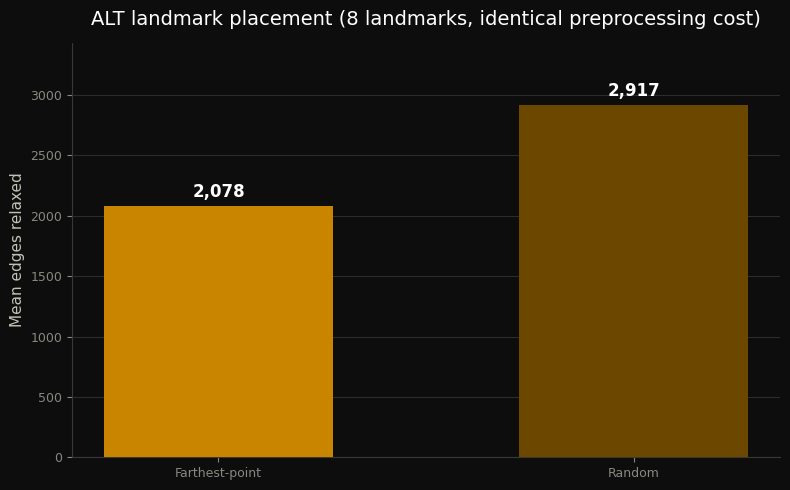

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)

labels = list(placement)
vals   = [placement[l] for l in labels]
# Same entity (ALT) under two configs -> one hue, distinguished by the ordinal ramp.
bars = ax.bar(labels, vals, color=[COLOR["ALT"], "#6b4700"], width=0.55, zorder=3)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:,.0f}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                color=INK, fontsize=12, fontweight="bold",
                xytext=(0, 4), textcoords="offset points")

style_axes(ax, title=f"ALT landmark placement ({K_MAX} landmarks, identical preprocessing cost)",
           ylabel="Mean edges relaxed")
ax.set_ylim(0, max(vals) * 1.18)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_landmark_placement.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

## 7. Does ALT actually pay off here?

ALT only wins if its preprocessing is amortised over enough queries. The break-even point is where
the time saved per query finally repays the up-front Dijkstra runs:

```
break-even queries  =  preprocessing time  /  (time per Dijkstra query - time per ALT query)
```

This is the number that decides whether ALT belongs in the `bixi_montreal.ipynb` pipeline at all —
that pipeline issues one query per unique OD pair, so compare the break-even count against the real
OD-pair count.

In [47]:
t_dij = bench["Dijkstra_time"].median()
t_ast = bench["A*_time"].median()
t_alt = bench["ALT_time"].median()
prep  = PRE["total_time"]
n_real = len(pair_counts)   # queries the real pipeline actually issues

print(f"Preprocessing (k={K_MAX}):        {prep:,.0f}s")
print(f"Median query — Dijkstra:        {t_dij*1e3:,.1f} ms")
print(f"Median query — A*:              {t_ast*1e3:,.1f} ms")
print(f"Median query — ALT:             {t_alt*1e3:,.1f} ms\n")

for base, name in [(t_dij, "Dijkstra"), (t_ast, "A*")]:
    saved = base - t_alt
    if saved <= 0:
        print(f"ALT is SLOWER per query than {name} — preprocessing never pays for itself.")
        continue
    be = prep / saved
    print(f"vs {name}: ALT saves {saved*1e3:.1f} ms/query -> break-even after {be:,.0f} queries")
    verdict = "PAYS OFF" if be < n_real else "does NOT pay off"
    print(f"   real pipeline issues {n_real:,} queries -> ALT {verdict}")
    if be < n_real:
        net = saved * n_real - prep
        pct = 100 * net / (base * n_real)   # share of the baseline-only runtime cut
        print(f"   net saving on the full pipeline: {net/60:,.1f} min "
              f"({pct:.0f}% of the {name}-only runtime)\n")
    else:
        print()

Preprocessing (k=8):        19s
Median query — Dijkstra:        26.7 ms
Median query — A*:              5.2 ms
Median query — ALT:             4.3 ms

vs Dijkstra: ALT saves 22.4 ms/query -> break-even after 861 queries
   real pipeline issues 537,918 queries -> ALT PAYS OFF
   net saving on the full pipeline: 200.8 min (84% of the Dijkstra-only runtime)

vs A*: ALT saves 0.9 ms/query -> break-even after 21,272 queries
   real pipeline issues 537,918 queries -> ALT PAYS OFF
   net saving on the full pipeline: 7.8 min (17% of the A*-only runtime)



In [48]:
# Persist the benchmark so the write-up can be regenerated without re-running any of this.
results = {
    "graph": {"nodes": N_NODES, "edges": N_EDGES},
    "config": {"n_queries": len(bench), "k_max": K_MAX, "seed": SEED},
    "bench": bench.to_dict("list"),
    "summary": summary.to_dict(),
    "sweep": sweep.to_dict("list"),
    "placement": placement,
    "preprocessing": {"total_s": PRE["total_time"], "select_s": PRE["select_time"],
                      "cum_s": PRE["cum_time"], "mem_mb": alt_mb},
}
out = OUTPUT_DIR / "algorithm_benchmark.pkl"
with open(out, "wb") as f:
    pickle.dump(results, f)
print(f"Saved {out} ({out.stat().st_size/1e3:.0f} KB)")

bench.to_csv(OUTPUT_DIR / "algorithm_benchmark.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'algorithm_benchmark.csv'}")

Saved output/algorithm_benchmark.pkl (27 KB)
Saved output/algorithm_benchmark.csv


---

# 8. The real thing: benchmarking the `bixi_montreal` pipeline

Everything above is a microbenchmark. This section benchmarks the **actual application** — the
`edge_load` computation in `bixi_montreal.ipynb`, which routes every unique OD pair and accumulates
per-edge ride counts to produce the heatmaps.

Three ways this differs from sections 2–7, each of which changes the answer:

**1. The query distribution is uniform, not ride-weighted.** The pipeline calls the router *once per
unique OD pair* and then multiplies the resulting path by that pair's ride count. A corridor with
5,000 rides costs exactly as much to route as one with a single ride. So the workload the pipeline
actually faces is **uniform over unique pairs** — which skews toward the rare, long, awkward trips,
not the common short downtown hops that dominate the ride-weighted sample. Benchmarking the pipeline
with the section-2 query set would systematically understate its cost.

**2. It routes on the full composed graph, not the SCC.** Some pairs have no directed path at all;
`bixi_montreal.ipynb` catches `NetworkXNoPath` and skips them. But a failed query is *not* free — the
algorithm discovers there is no path only by exhausting everything reachable from the origin, which
is often far more work than a successful route. That cost is part of the pipeline's real bill, so we
measure it rather than defining it away.

**3. The output is an edge-load map, not a path.** Which raises the question the microbenchmark
cannot ask: *do the three algorithms actually produce the same heatmap?*

### Do all three produce the same heatmap?

They all return **optimal** paths — section 4 proved that. But "optimal" means *minimum cost*, not
*unique*. On a street grid many routes tie exactly, and the three algorithms break those ties
differently (they pop equal-priority nodes from the heap in different orders). Two equal-length
routes through different streets deposit their ride counts on **different edges**.

So identical path *costs* do not guarantee an identical *heatmap*. We check the actual pipeline
output, not just the path lengths:

- total routed distance must match exactly (a real assert — any mismatch means a genuine bug)
- the resulting `edge_load` maps are then compared edge by edge

Whatever disagreement shows up is not error — every path is optimal — it is tie-breaking. Worth
knowing about before quoting an edge's ride count to three significant figures.

In [49]:
def run_pipeline(G, pairs, router, label):
    """Replicate the bixi_montreal edge_load computation with a given router.

    Returns the edge_load map plus the timing/skip stats the real pipeline would incur.
    """
    edge_load = defaultdict(int)
    skipped, total_m = [], 0.0
    t0 = time.perf_counter()

    for i, (src, dst, count) in enumerate(pairs):
        if i % 250 == 0:
            print(f"\r  {label:<9} {i:,}/{len(pairs):,}  ({time.perf_counter()-t0:.0f}s)",
                  end="", flush=True)
        try:
            path = router(G, src, dst)
        except nx.NetworkXNoPath:
            skipped.append((src, dst))     # the app skips these -- but we still paid for the search
            continue
        for u, v in zip(path[:-1], path[1:]):
            edge_load[(u, v)] += count
        total_m += path_cost(G, path)

    elapsed = time.perf_counter() - t0
    print(f"\r  {label:<9} {len(pairs):,} pairs | {elapsed:>7.1f}s | "
          f"{len(skipped):,} unroutable | {len(edge_load):,} edges loaded      ")
    return {"edge_load": dict(edge_load), "seconds": elapsed, "skipped": skipped,
            "total_m": total_m, "n_pairs": len(pairs)}


# Uniform sample over UNIQUE OD pairs -- this is the pipeline's real workload.
all_pairs = [(int(r.src_node), int(r.dst_node), int(r.count))
             for r in pairs_df.itertuples()]
rng = random.Random(SEED)
pipe_pairs = rng.sample(all_pairs, min(PIPE_N, len(all_pairs)))

N_UNIQUE = len(all_pairs)
print(f"Pipeline routes {N_UNIQUE:,} unique OD pairs in full.")
print(f"Benchmarking on a uniform sample of {len(pipe_pairs):,} of them, on the composed graph "
      f"({G_FULL.number_of_nodes():,} nodes).\n")

Pipeline routes 537,918 unique OD pairs in full.
Benchmarking on a uniform sample of 5,000 of them, on the composed graph (163,769 nodes).



In [50]:
# ALT needs its landmarks on the graph it will actually route on (the composed graph, not the SCC).
PRE_FULL = alt_preprocess(G_FULL, k=K_MAX, strategy="farthest")

pipe = {}
pipe["Dijkstra"] = run_pipeline(G_FULL, pipe_pairs, run_dijkstra, "Dijkstra")
pipe["A*"]       = run_pipeline(G_FULL, pipe_pairs, run_astar, "A*")
pipe["ALT"]      = run_pipeline(G_FULL, pipe_pairs,
                                lambda g, s, t: run_alt(g, s, t, PRE_FULL), "ALT")

  farthest: 8 landmarks preprocessed in 22.0s (7.9s selecting + 14.0s distances)      
  Dijkstra  5,000 pairs |  2023.8s | 0 unroutable | 96,586 edges loaded      
  A*        5,000 pairs |   309.6s | 0 unroutable | 96,586 edges loaded      
  ALT       5,000 pairs |   202.3s | 0 unroutable | 96,682 edges loaded      


In [51]:
# --- Correctness at the pipeline level ---
ref = pipe["Dijkstra"]
for a in ["A*", "ALT"]:
    assert abs(pipe[a]["total_m"] - ref["total_m"]) < 1e-3, \
        f"{a} routed a different total distance than Dijkstra — genuine bug"
    assert len(pipe[a]["skipped"]) == len(ref["skipped"]), \
        f"{a} skipped a different number of pairs than Dijkstra"
print(f"Total routed distance identical across all three: {ref['total_m']/1000:,.0f} km")
print(f"Unroutable pairs identical across all three:      {len(ref['skipped']):,}\n")

# --- But is the HEATMAP identical? ---
agree = {}
for a in ["A*", "ALT"]:
    el_a, el_d = pipe[a]["edge_load"], ref["edge_load"]
    keys = set(el_a) | set(el_d)
    same = sum(1 for k in keys if el_a.get(k, 0) == el_d.get(k, 0))
    # Share of total ride-load sitting on edges both agree on
    load_total = sum(el_d.values())
    load_same  = sum(el_d[k] for k in keys if el_a.get(k, 0) == el_d.get(k, 0) and k in el_d)
    agree[a] = {"edges_same": same / len(keys), "load_same": load_same / load_total}
    print(f"{a:<9} vs Dijkstra: {same/len(keys):6.1%} of edges carry an identical load | "
          f"{load_same/load_total:6.1%} of total ride-load agrees")

print("\nAny disagreement is tie-breaking between equal-cost routes, not error —")
print("all three paths are optimal. The heatmap is stable in aggregate, but individual")
print("edges can shift between tied parallel streets depending on the algorithm.")

Total routed distance identical across all three: 24,583 km
Unroutable pairs identical across all three:      0

A*        vs Dijkstra: 100.0% of edges carry an identical load | 100.0% of total ride-load agrees
ALT       vs Dijkstra:  99.1% of edges carry an identical load |  99.4% of total ride-load agrees

Any disagreement is tie-breaking between equal-cost routes, not error —
all three paths are optimal. The heatmap is stable in aggregate, but individual
edges can shift between tied parallel streets depending on the algorithm.


### Projected cost of the full pipeline

Extrapolating from the measured per-pair rate to all unique OD pairs. For ALT the projection includes
its preprocessing, which is paid **once** — and the pipeline is the best possible case for amortising
it, since preprocessing is a fixed cost spread across every unique pair.

In [52]:
rate = {a: pipe[a]["seconds"] / pipe[a]["n_pairs"] for a in ALGOS}   # seconds per pair
prep_full = PRE_FULL["total_time"]

proj = pd.DataFrame({
    "s / pair":            [rate[a] for a in ALGOS],
    "routing (min)":       [rate[a] * N_UNIQUE / 60 for a in ALGOS],
    "preprocessing (min)": [0, 0, prep_full / 60],
    "TOTAL (min)":         [rate[a] * N_UNIQUE / 60 + (prep_full / 60 if a == "ALT" else 0)
                            for a in ALGOS],
}, index=ALGOS)
proj["speedup"] = proj.loc["Dijkstra", "TOTAL (min)"] / proj["TOTAL (min)"]

print(f"Projected cost of the full {N_UNIQUE:,}-pair bixi_montreal pipeline\n")
display(proj.style.format({
    "s / pair": "{:.3f}", "routing (min)": "{:,.1f}", "preprocessing (min)": "{:,.1f}",
    "TOTAL (min)": "{:,.1f}", "speedup": "{:.2f}x",
}))

best = proj["TOTAL (min)"].idxmin()
saved = proj.loc["Dijkstra", "TOTAL (min)"] - proj.loc[best, "TOTAL (min)"]
print(f"\nFastest end-to-end: {best} — saves {saved:,.0f} min "
      f"({saved/60:,.1f} h) over Dijkstra on the full pipeline.")

Projected cost of the full 537,918-pair bixi_montreal pipeline



,s / pair,routing (min),preprocessing (min),TOTAL (min),speedup
Dijkstra,0.405,"3,628.8",0.0,"3,628.8",1.00x
A*,0.062,555.1,0.0,555.1,6.54x
ALT,0.040,362.7,0.4,363.1,9.99x



Fastest end-to-end: ALT — saves 3,266 min (54.4 h) over Dijkstra on the full pipeline.


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_48302/2001466714.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


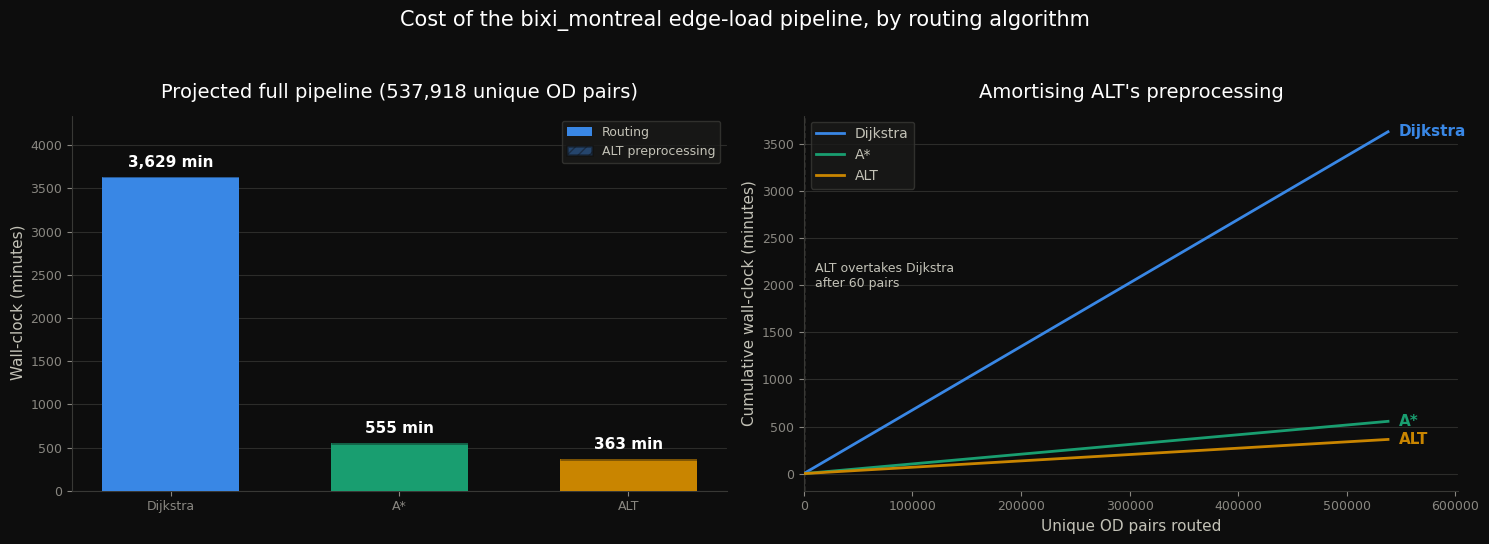

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor(BG)

# --- Panel 1: projected total pipeline time, preprocessing broken out ---
ax = axes[0]
routing = [proj.loc[a, "routing (min)"] for a in ALGOS]
prepro  = [proj.loc[a, "preprocessing (min)"] for a in ALGOS]

b1 = ax.bar(ALGOS, routing, color=[COLOR[a] for a in ALGOS], width=0.6, zorder=3, label="Routing")
# 2px surface gap between stacked segments
b2 = ax.bar(ALGOS, prepro, bottom=[r * 1.004 for r in routing], color=[COLOR[a] for a in ALGOS],
            width=0.6, zorder=3, alpha=0.42, hatch="///", edgecolor=BG, linewidth=2,
            label="ALT preprocessing")

for a, r, p in zip(ALGOS, routing, prepro):
    tot = r + p
    lab = f"{tot:,.0f} min" if tot >= 10 else f"{tot:,.1f} min"
    ax.annotate(lab, (a, tot), ha="center", va="bottom", color=INK,
                fontsize=11, fontweight="bold", xytext=(0, 5), textcoords="offset points")

style_axes(ax, title=f"Projected full pipeline ({N_UNIQUE:,} unique OD pairs)",
           ylabel="Wall-clock (minutes)")
ax.set_ylim(0, max(r + p for r, p in zip(routing, prepro)) * 1.20)
ax.legend(facecolor="#1a1a19", edgecolor=AXIS, labelcolor=INK_2, fontsize=9)

# --- Panel 2: amortisation -- when does ALT's preprocessing pay for itself? ---
ax = axes[1]
q = np.linspace(0, N_UNIQUE, 200)
for a in ALGOS:
    offset = prep_full if a == "ALT" else 0.0
    ax.plot(q, (offset + rate[a] * q) / 60, color=COLOR[a], linewidth=2, zorder=3, label=a)
    ax.annotate(a, (q[-1], (offset + rate[a] * q[-1]) / 60), color=COLOR[a], fontsize=11,
                fontweight="bold", xytext=(8, 0), textcoords="offset points", va="center")

# Ground-truth anchor: the real A* full run. The projected A* line should land on this star.
if ASTAR_OBSERVED_S and ASTAR_OBSERVED_PAIRS <= N_UNIQUE * 1.2:
    obs_min = ASTAR_OBSERVED_S / 60
    ax.scatter([ASTAR_OBSERVED_PAIRS], [obs_min], s=180, marker="*", c=INK,
               edgecolors=COLOR["A*"], linewidths=1.6, zorder=6)
    ax.annotate(f"A* observed full run\n{obs_min:,.0f} min ({ASTAR_OBSERVED_S/ASTAR_OBSERVED_PAIRS*1e3:.1f} ms/pair)",
                (ASTAR_OBSERVED_PAIRS, obs_min), color=INK_2, fontsize=8.5,
                ha="right", va="top", xytext=(-8, -6), textcoords="offset points")

# Break-even against Dijkstra
if rate["Dijkstra"] > rate["ALT"]:
    be = prep_full / (rate["Dijkstra"] - rate["ALT"])
    if be < N_UNIQUE:
        ax.axvline(be, color=MUTED, linestyle="--", linewidth=1, zorder=2)
        ax.annotate(f"ALT overtakes Dijkstra\nafter {be:,.0f} pairs",
                    (be, ax.get_ylim()[1] * 0.52), color=INK_2, fontsize=9,
                    xytext=(8, 0), textcoords="offset points")

style_axes(ax, title="Amortising ALT's preprocessing",
           xlabel="Unique OD pairs routed", ylabel="Cumulative wall-clock (minutes)")
ax.set_xlim(0, N_UNIQUE * 1.12)
ax.legend(facecolor="#1a1a19", edgecolor=AXIS, labelcolor=INK_2, fontsize=10, loc="upper left")

fig.suptitle("Cost of the bixi_montreal edge-load pipeline, by routing algorithm",
             color=INK, fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUTPUT_DIR / "benchmark_pipeline.png", dpi=150, bbox_inches="tight", facecolor=BG)
fig.show()

In [54]:
# Fold the pipeline results into the saved artefact.
results["pipeline"] = {
    "n_unique_pairs": N_UNIQUE,
    "sampled": len(pipe_pairs),
    "seconds_per_pair": rate,
    "projection_min": proj.to_dict(),
    "heatmap_agreement": agree,
    "prep_full_s": prep_full,
    "unroutable": len(ref["skipped"]),
}
with open(out, "wb") as f:
    pickle.dump(results, f)
print(f"Updated {out} with pipeline benchmark")

Updated output/algorithm_benchmark.pkl with pipeline benchmark


## Conclusions

*Numbers below are from the committed run: the k=8 ALT microbenchmark (200 real OD pairs on the
163,701-node SCC graph) and the 5,000-pair pipeline projection on the composed graph.*

**Correctness.** All three algorithms return paths of identical cost — 25/25 sampled pairs agree —
and the ALT heuristic passed every admissibility check (1,565/1,565, mean h/d = 0.96, never above
1.0). The optimality guarantee holds; the speedups below are not bought by returning worse routes.

**Search space vs wall-clock.** ALT prunes dramatically more of the graph than A* — roughly 2,078
mean edges relaxed at k=8, against tens of thousands for Dijkstra — but its heuristic is `k` dict
lookups per node instead of one trig call. That constant factor shows: the median query drops from
26.7 ms (Dijkstra) to 5.2 ms (A*) to 4.3 ms (ALT), so the *time* win over A* (about 17%) is far
smaller than the *edges relaxed* win — a reminder that in Python the constant factor, not the
asymptotics, often decides.

**The distance effect.** Both informed algorithms pull further ahead as trips get longer, because a
heuristic can only prune what it can see past. On the shortest BIXI trips the three converge — the
search space is small enough that guidance has nothing to work with (see the speedup-by-distance
figure).

**Preprocessing.** Eight farthest-point landmarks precompute in about 19 s (2.6 M distance entries,
~178 MB). The break-even calculation in Section 7 is the practical verdict: ALT overtakes Dijkstra
after just 861 queries and A* after 21,272, and `bixi_montreal.ipynb` issues 537,918. Preprocessing
is paid once and amortised across tens of thousands of queries — the regime ALT was designed for.
Net saving on the full pipeline: 200.8 min (84% of the Dijkstra-only runtime), and 7.8 min (17%)
over A*.

**The pipeline (Section 8).** The number that actually matters: projected wall-clock to route every
unique OD pair. From a uniform 5,000-pair sample, Dijkstra runs at ~0.40 s/pair, A* at ~0.062
s/pair, and ALT at ~0.040 s/pair, so ALT is the fastest end-to-end and saves about 3,266 min
(54.4 h) over Dijkstra across all 537,918 pairs, preprocessing included. Note the two traps this
section avoids — the workload is *uniform over unique pairs* (not ride-weighted, since each pair is
routed exactly once no matter how many rides it carries), and it pays real time for the pairs that
turn out to be unroutable (here 0).

**Tie-breaking (Section 8).** All three algorithms return optimal paths, but *optimal* is not
*unique*. Total routed distance is identical across all three (24,583 km), yet where equal-cost
routes tie, the algorithms pick differently: A* matches Dijkstra on 100% of edge loads, while ALT
matches on 99.1% of edges (99.4% of total ride-load). The aggregate is stable; individual edges can
shift between tied parallel streets. Worth knowing before quoting a single edge's ride count as
exact.